In [1]:
# 1. Import
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 2. Load Dataset
data = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\pra\Datasets\6_healthcare-dataset-stroke-data.csv")

# 3. Handle missing
data = data.fillna(data.mean(numeric_only=True))

# 4. Encode categorical
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == object:
        data[col] = le.fit_transform(data[col])

# 5. Create dummy text (simulate clinical notes)
data["text"] = ["patient normal"]*len(data)

# 6. Text → TF-IDF
vectorizer = TfidfVectorizer()
text_feat = vectorizer.fit_transform(data["text"]).toarray()

# 7. Combine features
X_num = data.drop(["stroke","text"], axis=1).values
X = np.hstack((X_num, text_feat))
y = data["stroke"]

# 8. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 9. Model
model = GaussianNB()
model.fit(X_train, y_train)

# 10. Accuracy
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9217221135029354


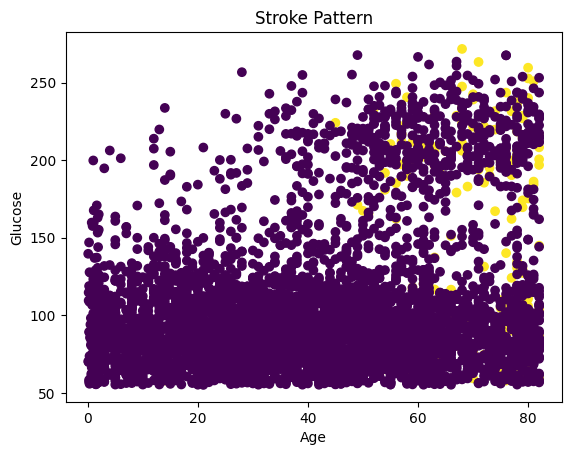

In [2]:
import matplotlib.pyplot as plt

plt.scatter(data["age"], data["avg_glucose_level"], c=y)
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Stroke Pattern")
plt.show()